# Postprocessing

In [86]:
# Suppress Possible Warnings : In some installations a warning due to pyg_lib path can arise: not relevant to our setting
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*An issue occurred while importing 'pyg-lib'.*",
    category=UserWarning,
    module="torch_geometric.typing"
)
warnings.filterwarnings(
    "ignore",
    message=".*An issue occurred while importing 'torch-sparse'.*",
    category=UserWarning,
    module="torch_geometric.typing"
)

In [87]:
import re
import torch
import logging
import numpy as np
import networkx as nx
import torch.nn as nn
import pandas as pd
from scipy.stats import iqr
import torch_geometric.utils as pyg_utils
from torch_geometric.utils import to_dense_adj
from torch_geometric import seed_everything
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

from src.config import set_run_dir
from src.config import set_out_dir
from src.config import load_cfg
from src.logger import setup_printing
from src.utils.device import auto_select_device
from src.model.factory import create_model
from src.train.optim import create_optimizer, create_scheduler
from src.dataset.loader import load_data_and_create_dataloader
from src.train.create_trainer import create_trainer
from src.train.optim import create_criterion
from src.utils.plots import plot_node_forecasting
from src.train.task import create_task
from src.metric.anomaly_score import get_detection_metrics
from src.utils.plots import plot_confusion_matrix, plot_roc_auc


### Load trained model

In [88]:
cfg_file = 'run/configs/swat/gdn-pretrained.yaml'
cfg = load_cfg(cfg_file)
set_out_dir(cfg.out_dir, cfg_file)
set_run_dir(cfg.out_dir, cfg.seed)

cfg.print = 'stdout'
cfg.train.shuffle = False
cfg.train.batch_size = 256
auto_select_device()

seed_everything(cfg.seed)
setup_printing(logging.INFO)

INFO     Using CPU for training
INFO     Mon Sep  1 07:48:15 2025


In [89]:
loaders, scaler = load_data_and_create_dataloader()

INFO     
Loaded data from run/datasets/swat
------------ Basic -----------
# Samples: 92496
# Node: 45
# Edges: 1980
# Sequence Length: 5
------------ Fault ratio -----------
# Ratio of fault samples train: 0.000
# Ratio of fault samples test: 0.122
------------ Scaling -----------
[6.68e-01 5.38e-01 8.57e-01 7.42e-01 0.00e+00 6.91e-01 2.45e-01 1.76e-01
 7.31e-01 8.70e-01 0.00e+00 7.40e-01 0.00e+00 6.66e-01 0.00e+00 7.85e-01
 7.76e-01 8.79e-01 5.03e-01 8.99e-01 5.10e-01 5.12e-01 2.63e-05 8.23e-01
 8.41e-01 2.36e-01 9.77e-01 8.72e-01 1.00e+00 0.00e+00 1.00e+00 9.20e-01
 2.47e-01 4.70e-01 1.38e-02 9.77e-01 9.34e-01 9.69e-01 9.74e-01 1.00e+00
 9.56e-01 3.25e-01 9.58e-01 8.07e-03 7.77e-03]
------------ Split -----------
   Train: 38011/92496
Validate: 9499/92496
    Test: 44986/92496



In [90]:
model = create_model(cfg.model.type)

INFO     Model GDN parameters: 3841, deployed to cpu
INFO     GDN(
  (embedding): Embedding(45, 64)
  (bn_outlayer_in): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act): ReLU()
  (gnn_layers): ModuleList(
    (0): GNNLayer(
      (gnn): GraphLayer(5, 64, heads=1)
      (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU()
    )
  )
  (out_layer): OutLayer(
    (mlp): ModuleList(
      (0): Linear(in_features=64, out_features=1, bias=True)
    )
  )
  (dp): Dropout(p=0.2, inplace=False)
)


In [91]:
optimizer = create_optimizer(model.parameters())
scheduler = create_scheduler(optimizer)

crit_type = cfg.optim.criterion
criterion = create_criterion(crit_type, mask_loss=False)

task = create_task(
    cfg.task.type,
    task_train_type=cfg.task.train_type,
    track_graph=False,
)

trainer = create_trainer(
    model,
    optimizer=optimizer,
    neptune_writer=None,
    scheduler=scheduler,
    criterion=criterion,
    scaler=scaler,
    task=task,
)

INFO     Create AnomalyDetectionTask.
INFO     Create ForecastingTrainer.


In [92]:
trainer.load(model)
model.eval()

INFO     Model GDN saved in run/results/anomaly/swat/gdn-pretrained/5/model.pt loaded to cpu, best epoch 27 with eval err 0.34571 and test err 2792.49023


GDN(
  (embedding): Embedding(45, 64)
  (bn_outlayer_in): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act): ReLU()
  (gnn_layers): ModuleList(
    (0): GNNLayer(
      (gnn): GraphLayer(5, 64, heads=1)
      (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU()
    )
  )
  (out_layer): OutLayer(
    (mlp): ModuleList(
      (0): Linear(in_features=64, out_features=1, bias=True)
    )
  )
  (dp): Dropout(p=0.2, inplace=False)
)

In [93]:
train_loader, val_loader, test_loader = loaders

In [94]:
# read out features from run/datasets/swat/features.txt with column name feature
feature_map = pd.read_csv('run/datasets/swat/features.txt', header=None, names=['feature'])
feature_map = feature_map['feature'].to_dict()
feature_list = list(feature_map.values())
feature_list

['FIT101',
 'LIT101',
 'MV101',
 'P101',
 'P102',
 'AIT201',
 'AIT202',
 'AIT203',
 'FIT201',
 'MV201',
 'P201',
 'P203',
 'P204',
 'P205',
 'P206',
 'DPIT301',
 'FIT301',
 'LIT301',
 'MV301',
 'MV302',
 'MV303',
 'MV304',
 'P301',
 'P302',
 'AIT401',
 'AIT402',
 'FIT401',
 'LIT401',
 'P402',
 'P403',
 'UV401',
 'AIT501',
 'AIT502',
 'AIT503',
 'AIT504',
 'FIT501',
 'FIT502',
 'FIT503',
 'FIT504',
 'P501',
 'PIT501',
 'PIT502',
 'PIT503',
 'FIT601',
 'P602']

### Evaluate the model on the validation and test set

In [95]:
trainer.eval_epoch(test_loader, 'eval')
eval_preds = torch.cat(trainer.loggers['eval']._pred).detach().cpu().numpy()
eval_trues = torch.cat(trainer.loggers['eval']._true).detach().cpu().numpy()

/Users/rtheiler/Workspaces/work/IMC-2025-GNN-Workshop/repository_public/.venv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:143: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


In [96]:
trainer.eval_epoch(test_loader, 'test')
test_preds = torch.cat(trainer.loggers['test']._pred).detach().cpu().numpy()
test_trues = torch.cat(trainer.loggers['test']._true).detach().cpu().numpy()
test_true_labels = torch.cat(trainer.loggers['test']._custom_stats['label']).detach().cpu().numpy()

### Evaluate forecasting performance

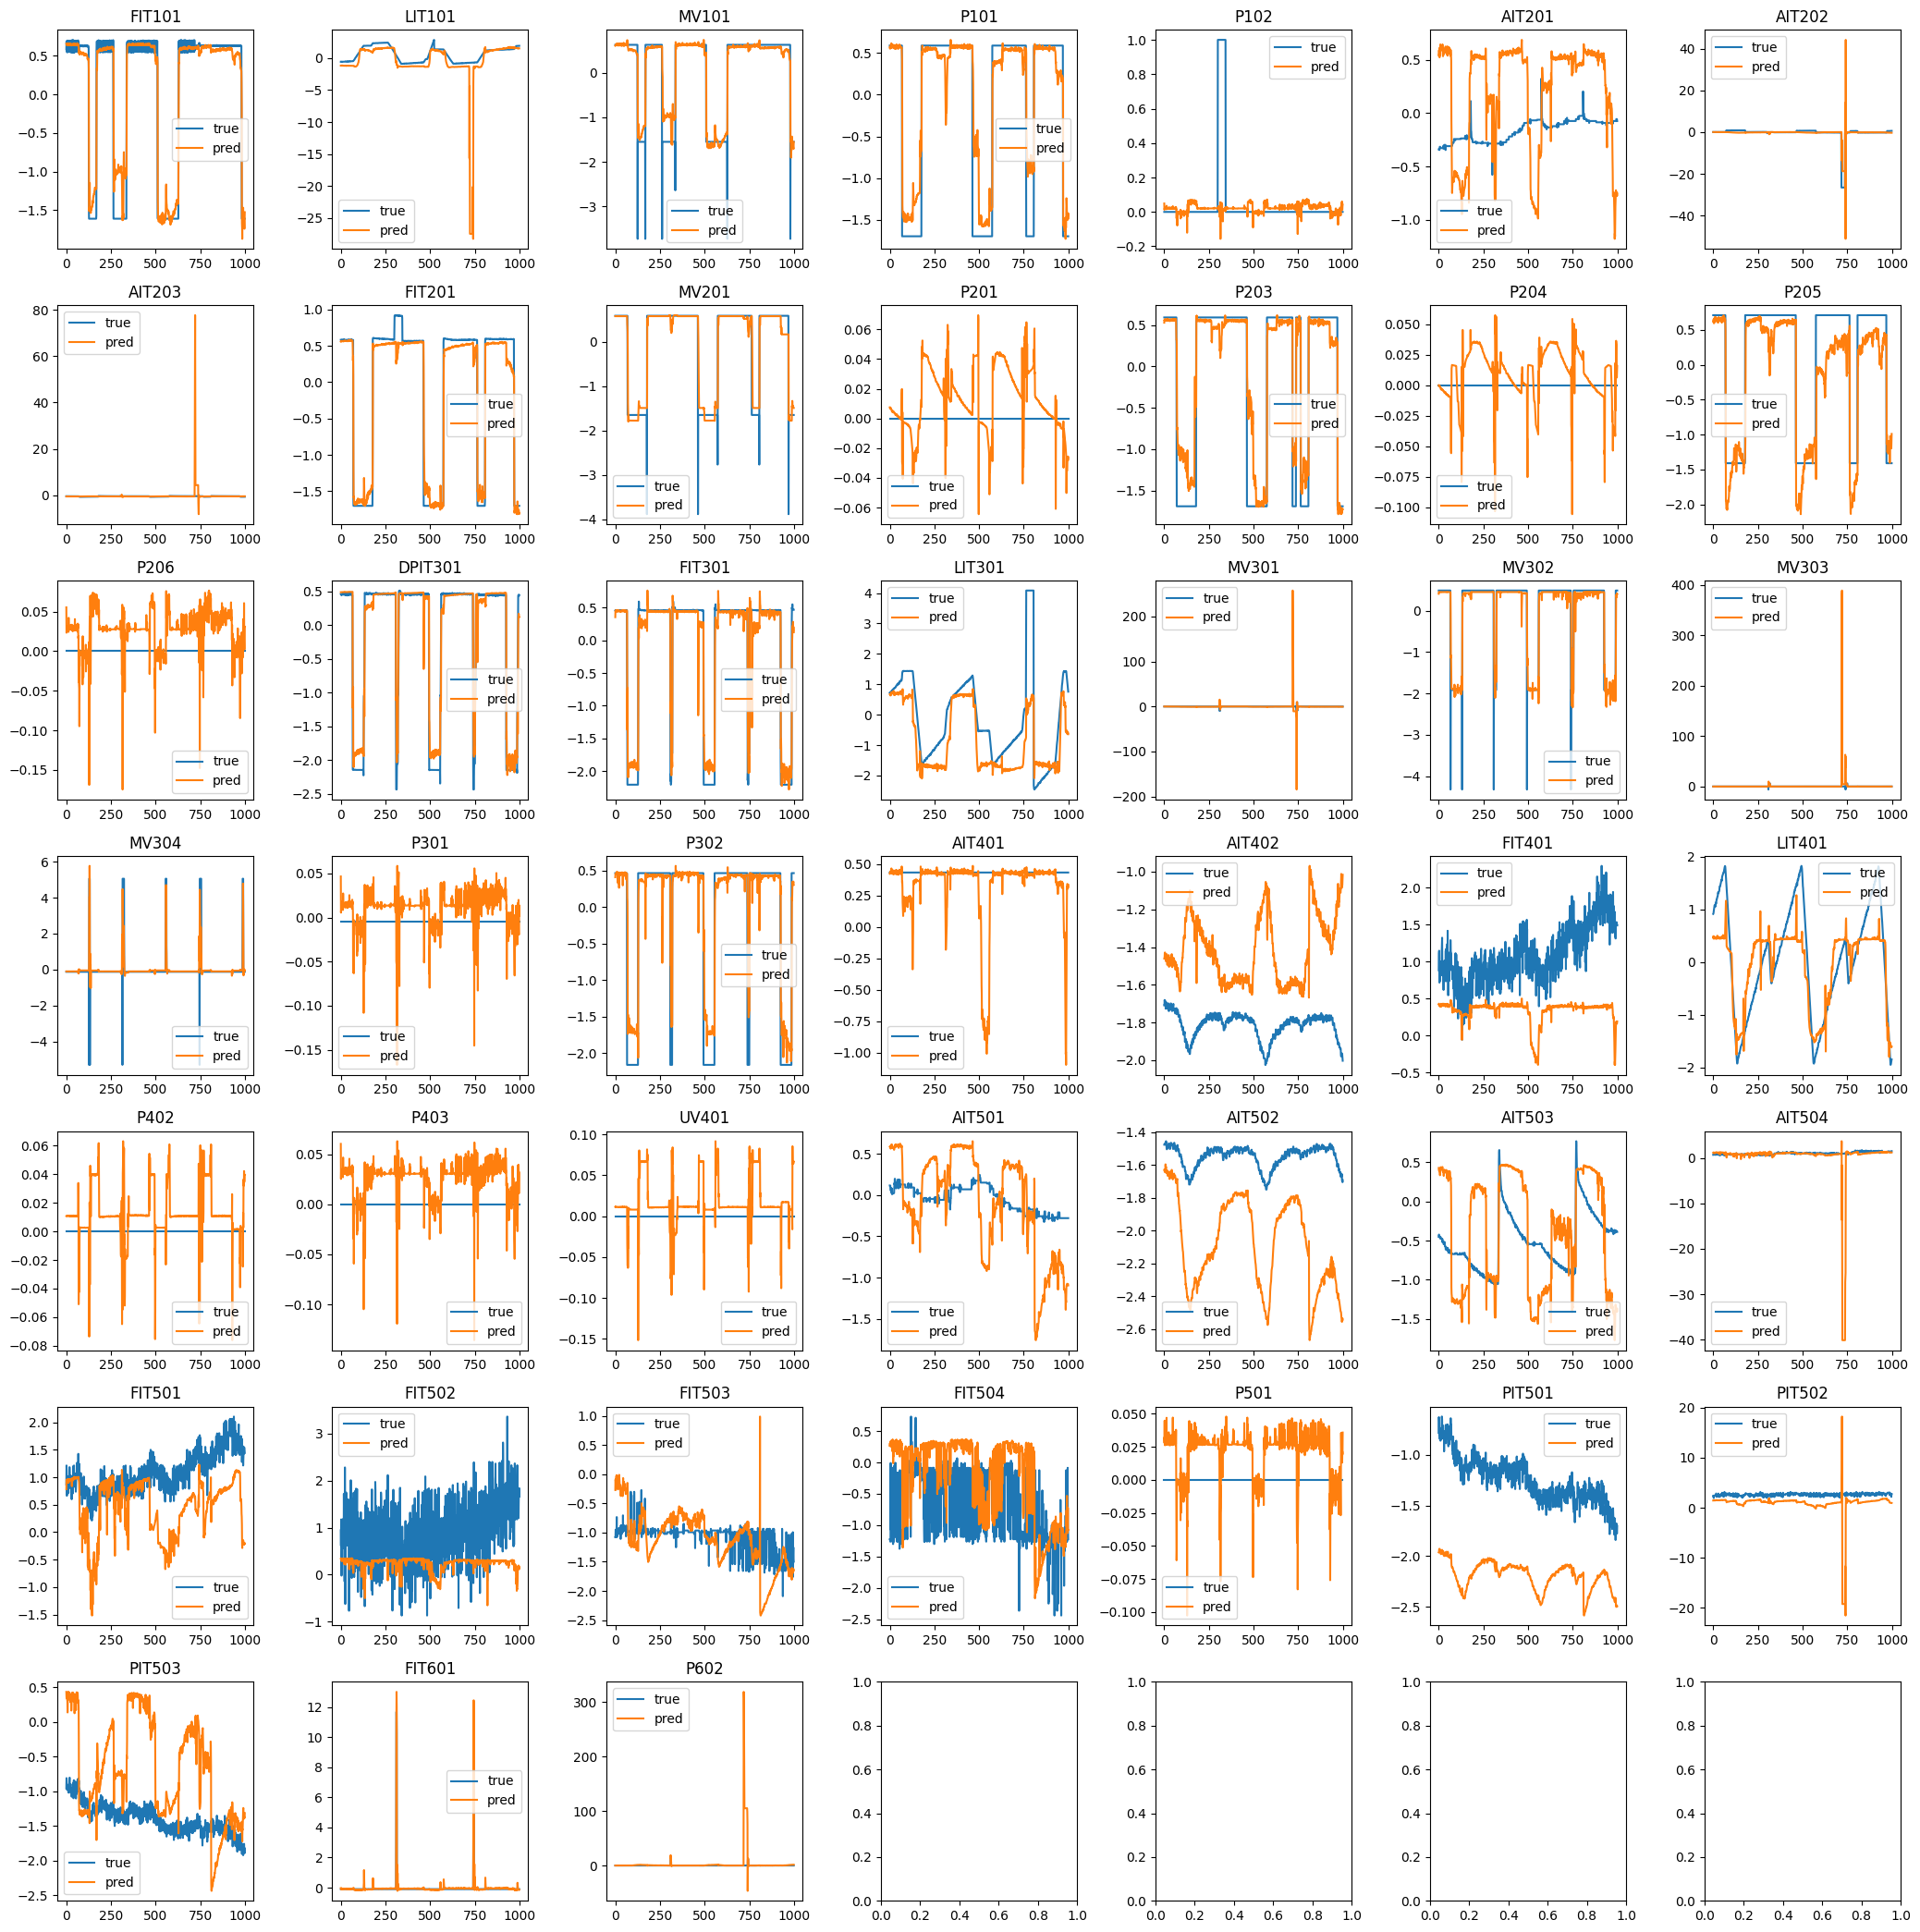

In [97]:
f = plot_node_forecasting(eval_preds[:, 0], eval_trues[:, 0], (0, 1000), labels=feature_list)
plt.tight_layout()

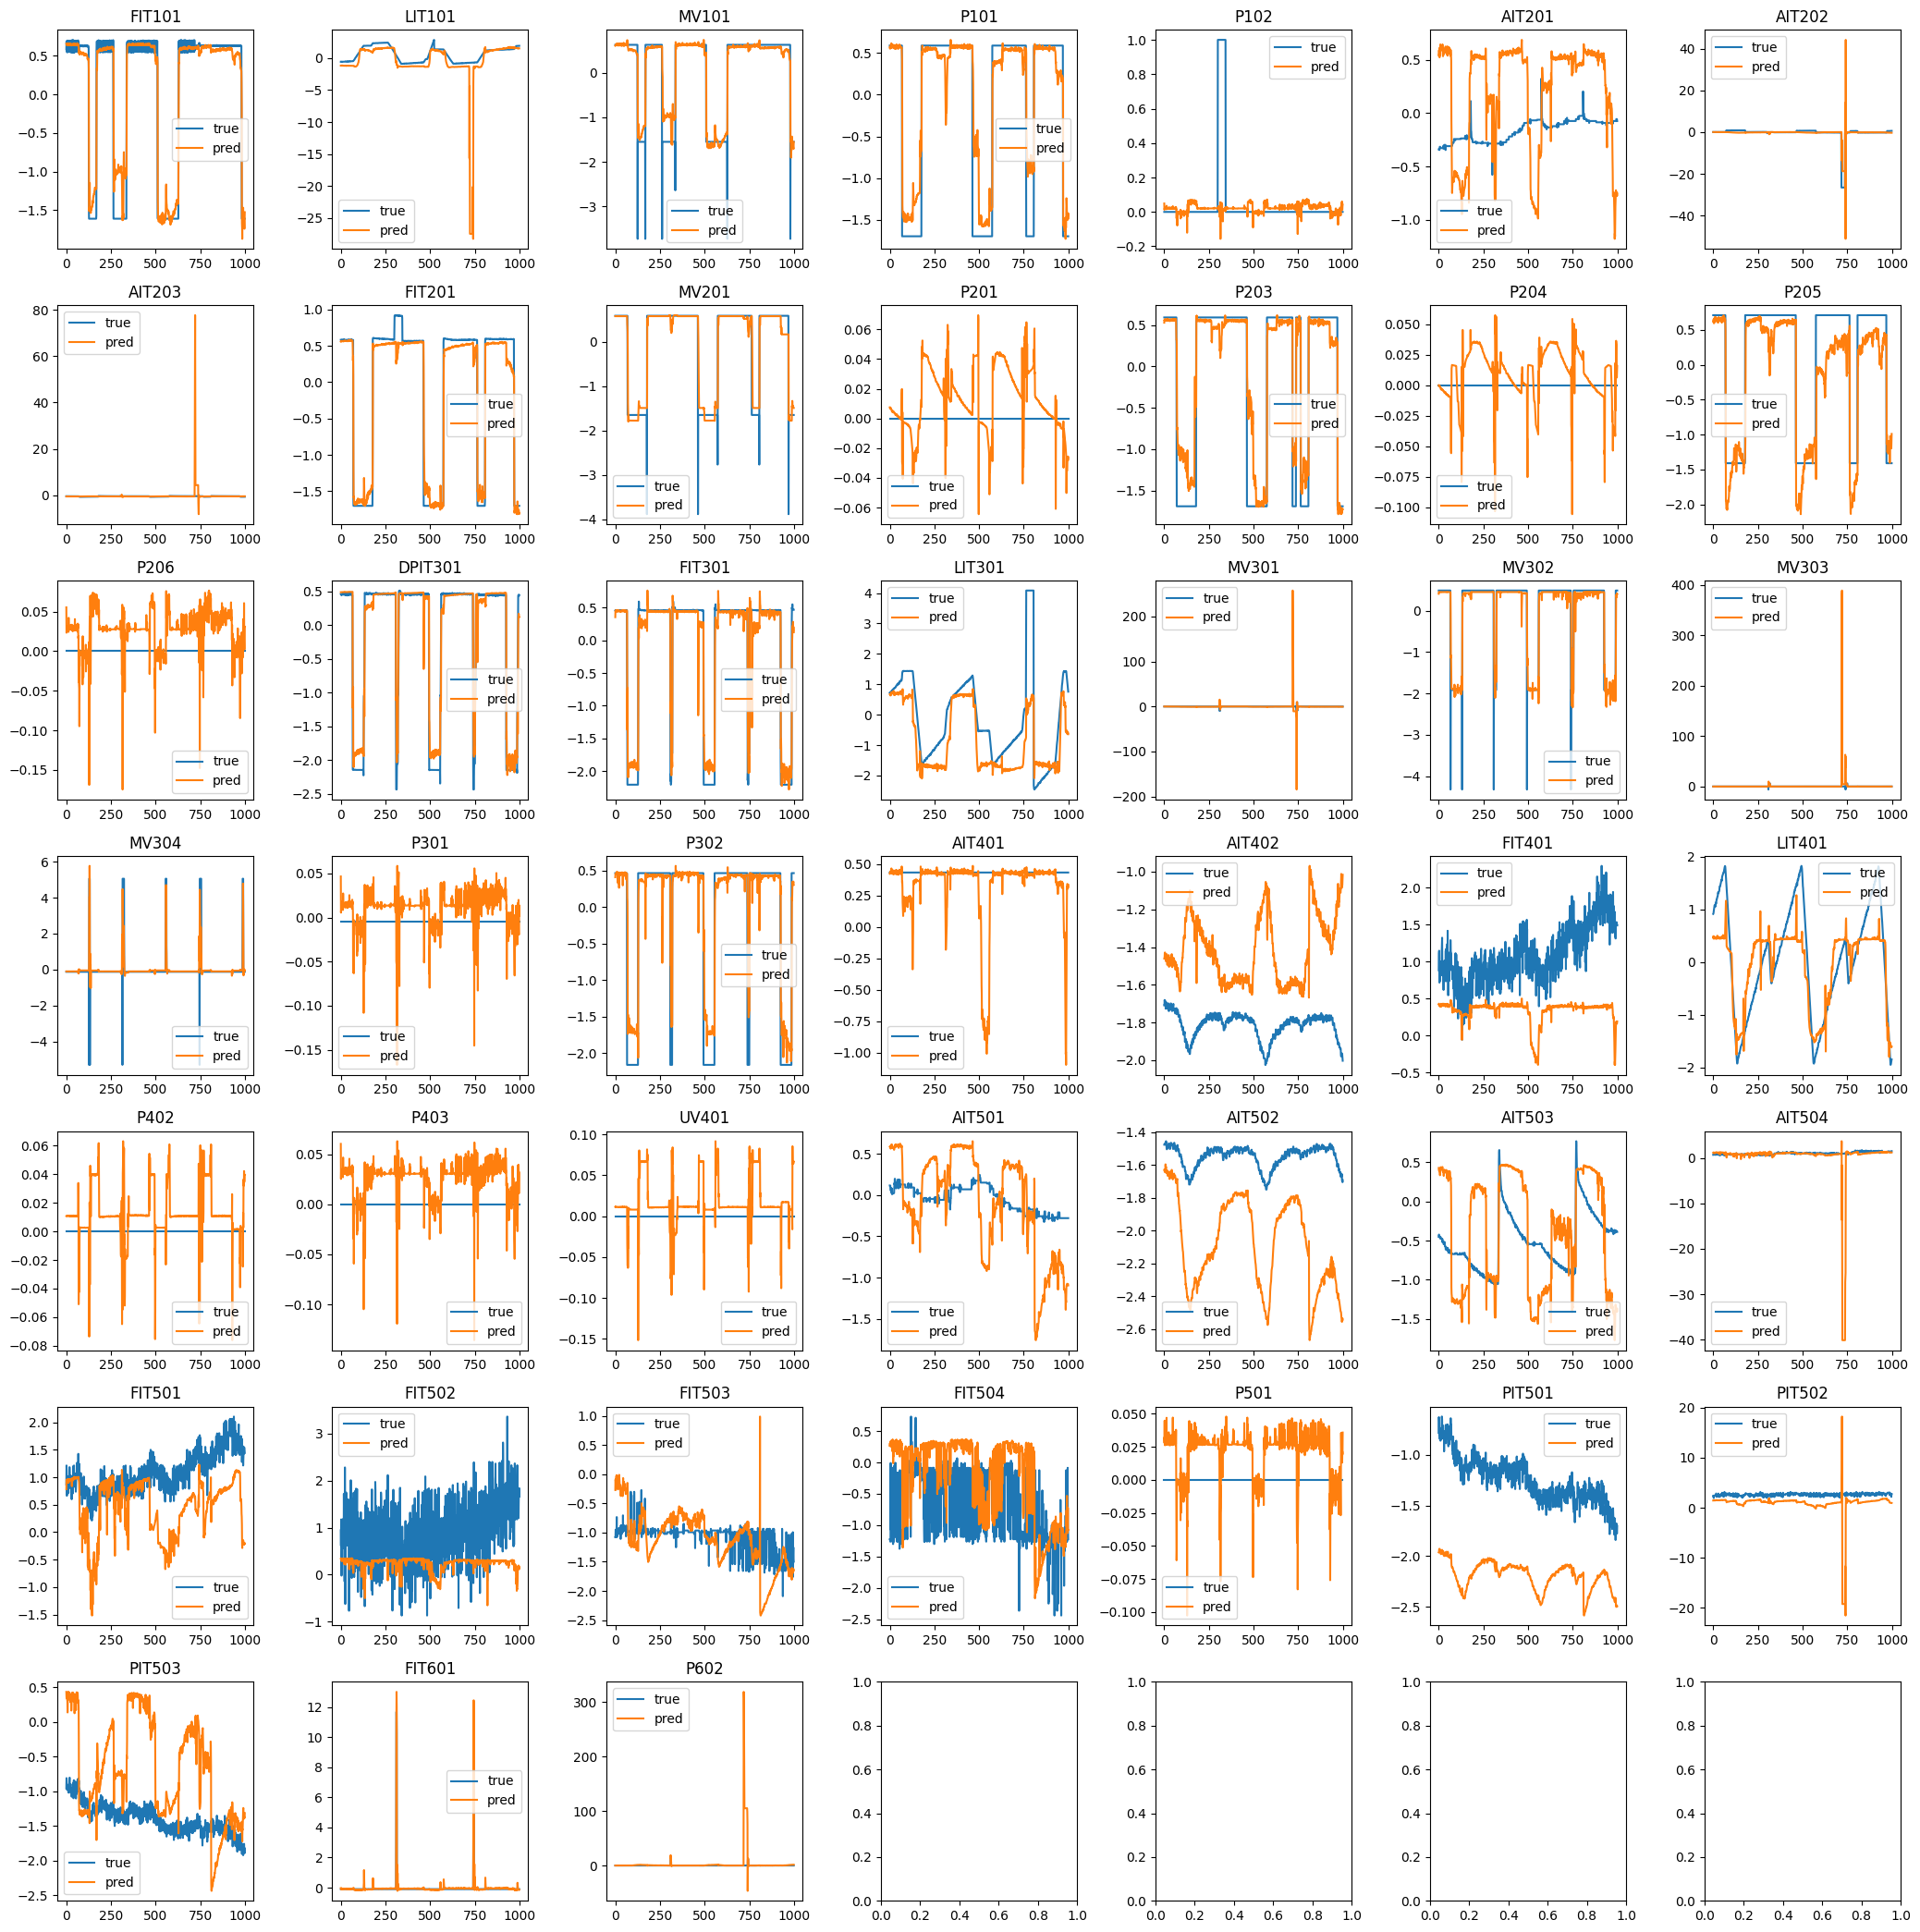

In [98]:
f = plot_node_forecasting(test_preds[:, 0], test_trues[:, 0], (0, 1000), labels=feature_list)
plt.tight_layout()

### Ex1: Anomaly detection performance evaluation

**Objective:**
Calculate the anomaly score and evaluate the anomaly detection performance of a sensor network.

**Tasks:**

1. **Error calculation:**
   - Compute the error for each sensor \(i\) at time \(t\) using:
      $Err_i (t) = |s(t)^{(i)} − \hat{s}^{(t)}|$

2. **Robust sensor normalization:**
   - Normalize the error values to account for different sensor characteristics:
     $a_i^{(t)} =  \frac{Err_i^{(t)} − \tilde{\mu_i}}{\tilde{\sigma_i}}$
   - Here, $\tilde{\mu_i}$ is the median and  $\tilde{\sigma_i}$ is the inter-quartile range (IQR) of $Err_i{(t)}$ over time.

3. **Anomaly score calculation:**
   - Compute the overall anomaly score at time \(t\) by taking the maximum normalized error across all sensors:
     $A(t) = \max_{i} a_i(t)$

4. **Performance evaluation:**
   - Evaluate the anomaly detection performance (F1 score, confusion matric, AUC) using the computed anomaly scores.


#### Calucalte the anomaly score and evaluate the anomaly detection performance

In [99]:
def get_err_median_and_iqr(predicted, groundtruth, rng=(25, 75)):

    np_arr = np.abs(np.subtract(np.array(predicted), np.array(groundtruth)))
    err_median = np.median(np_arr, axis=0)
    err_iqr = iqr(np_arr, rng=rng, axis=0)

    return err_median, err_iqr

def get_ad_score_by_node(pred, true, epsilon=1e-2, rng=(25, 75), n_err_mid=None, n_err_iqr=None):
    pred = pred.squeeze()
    true = true.squeeze()

    if n_err_mid is None and n_err_iqr is None:
        n_err_mid, n_err_iqr = get_err_median_and_iqr(pred, true, rng)

    test_delta = np.abs(np.subtract(
                        np.array(pred).astype(np.float64),
                        np.array(true).astype(np.float64)
                    ))

    err_scores = (test_delta - n_err_mid) / (np.abs(n_err_iqr) + epsilon)


    # smoothing
    smoothed_err_scores = err_scores.copy()
    before_num = 3
    for i in range(before_num, len(err_scores)):
        smoothed_err_scores[i] = np.mean(err_scores[i-before_num:i+1], axis=0)

    return smoothed_err_scores, n_err_mid, n_err_iqr

def get_ad_topk_ad_score(score_by_node, topk=1):
    # select top k errors for each graph (GDN)
    n_nodes = cfg.dataset.n_nodes
    topk_indices = np.argpartition(score_by_node, range(n_nodes-topk-1, n_nodes), axis=1)[:, -topk:]
    score = np.sum(np.take_along_axis(score_by_node, topk_indices, axis=1), axis=1)
    return score


In [100]:
n_nodes = cfg.dataset.n_nodes
window_size = cfg.dataset.horizon

eval_preds_by_nodes = eval_preds.reshape(-1, n_nodes, window_size)
eval_trues_by_nodes = eval_trues.reshape(-1, n_nodes, window_size)
test_preds_by_nodes = test_preds.reshape(-1, n_nodes, window_size)
test_trues_by_nodes = test_trues.reshape(-1, n_nodes, window_size)

In [101]:
# Validation score
val_score, err_iqr, err_median = get_ad_score_by_node(
    eval_trues_by_nodes, eval_preds_by_nodes, n_err_iqr=None, n_err_mid=None,
)

# # Test score
test_score, _, _ = get_ad_score_by_node(
    test_trues_by_nodes, test_preds_by_nodes, n_err_iqr=err_iqr, n_err_mid=err_median,
)

In [102]:
pd.DataFrame(test_topk_score).describe()


,0
count,44986.000000
mean,423.627341
std,1423.972853
min,0.140610
25%,0.761301
50%,2.009282
75%,27.851261
max,15381.671462


In [103]:
pd.DataFrame(eval_topk_score).describe()

,0
count,44986.000000
mean,466.228883
std,1590.284740
min,0.038068
25%,0.824577
50%,1.557639
75%,19.768028
max,15896.161698


In [105]:
eval_topk_score = get_ad_topk_ad_score(val_score)
test_topk_score = get_ad_topk_ad_score(test_score)

threshold = np.mean(eval_topk_score)
pred_labels = test_topk_score > threshold
print(threshold)


eval_topk_score.shape
out = get_detection_metrics(test_true_labels, pred_labels, test_topk_score, fault_labels=None, threshold=threshold)
out

466.2288827844321


{'ambiguity': 0.26035,
 'accuracy': 0.95101,
 'precision': 0.99111,
 'recall': 0.61389,
 'f1': 0.75817,
 'auc': 0.86983,
 'pa': 0.75272,
 'tn': np.float64(0.87421),
 'fp': np.float64(0.00069),
 'fn': np.float64(0.0483),
 'tp': np.float64(0.0768),
 'tp_rate': np.float64(0.61389),
 'fp_rate': np.float64(0.00079),
 'fpr': array([0.        , 0.        , 0.        , ..., 0.99860257, 0.99860257,
        1.        ], shape=(3431,)),
 'tpr': array([0.00000000e+00, 1.77683014e-04, 7.10732054e-04, ...,
        9.99822317e-01, 1.00000000e+00, 1.00000000e+00], shape=(3431,))}

#### Plot the confusion matrix and ROC curve

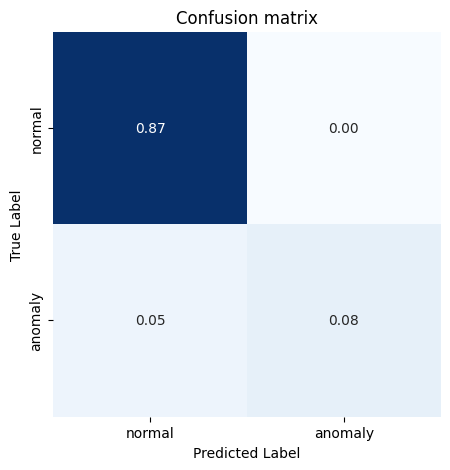

In [107]:
fig = plot_confusion_matrix(out['tn'], out['fp'], out['fn'], out['tp'],
                            labels=['normal', 'anomaly'],
                            title='Confusion matrix')

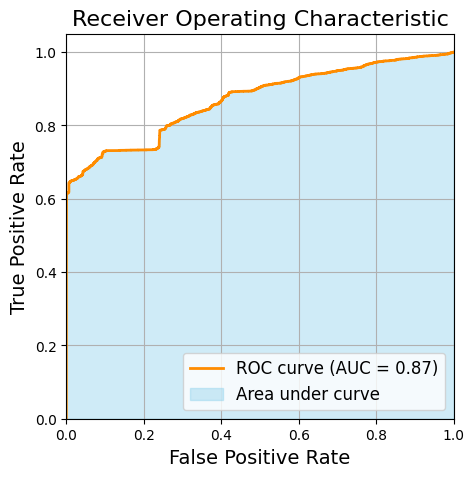

In [108]:
fig = plot_roc_auc(out['fpr'], out['tpr'], out['auc'])

### Ex2: Interpret sensor embedding
To explain the learned model, we can visualize its sensor embedding vectors.
Sensors can be grouped by their type (e.g., "FIT", "PIT") or by their component number, which is indicated by the first digit in the sensor name (e.g., "2" in "AIT203").

**Task:** Visualize the sensor embedding vectors in 2D space using t-SNE, grouping the sensors by their type and component number to explore patterns and similarities.


![image.png](img/swat_process.png)

In [109]:
def extract_sensor_type(component_id):
    return re.match(r'[^\d]+', component_id).group(0)

sensor_component_id = [fn[-3] for fn in feature_list]

df_sensor_embedding = pd.DataFrame({
    'sensor_name': feature_list,
    'sensor_component_id': sensor_component_id,
})

df_sensor_embedding['sensor_type'] = df_sensor_embedding['sensor_name'].apply(extract_sensor_type)
df_sensor_embedding.head()

,sensor_name,sensor_component_id,sensor_type
0,FIT101,1,FIT
1,LIT101,1,LIT
2,MV101,1,MV
3,P101,1,P
4,P102,1,P


In [110]:
sensor_embeddings = model.embedding.weight.detach().cpu().numpy()
sensor_embeddings.shape

tsne = TSNE(n_components=2, verbose=1, perplexity=40)
tsne_results = tsne.fit_transform(sensor_embeddings)

df_sensor_embedding['tsne1'] = tsne_results[:, 0]
df_sensor_embedding['tsne2'] = tsne_results[:, 1]

[t-SNE] Computing 44 nearest neighbors...
[t-SNE] Indexed 45 samples in 0.000s...
[t-SNE] Computed neighbors for 45 samples in 0.116s...
[t-SNE] Computed conditional probabilities for sample 45 / 45
[t-SNE] Mean sigma: 1.688023
[t-SNE] KL divergence after 250 iterations with early exaggeration: 39.494736
[t-SNE] KL divergence after 1000 iterations: 0.005903


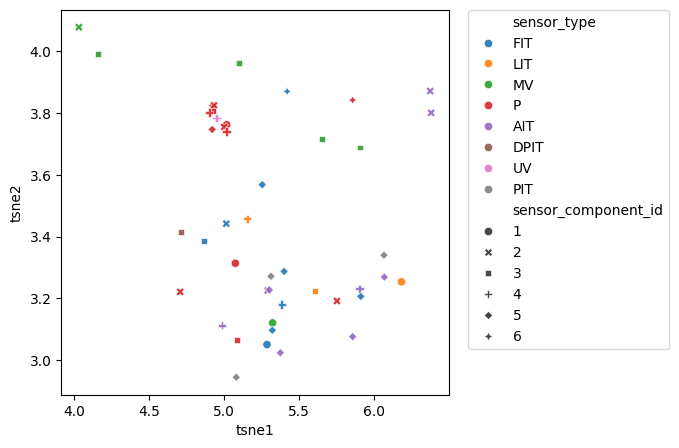

In [111]:
plt.figure(figsize=(5, 5))
sns.scatterplot(
    x='tsne1', y='tsne2',
    style='sensor_component_id',
    hue='sensor_type',
    data=df_sensor_embedding,
    legend="full",
    alpha=0.9
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

### Ex3: Interpret learned graph for anomaly localization
Leverage the learned graph from a Graph Neural Network (GNN) to identify and localize anomalies in a sensor network.

**Task:**
1. **Graph Analysis:**
   - Analyze edges to understand relationships between sensors.
   - Use attention weights to determine the importance of neighboring sensors.

2. **Anomaly Localization:**
   - Identify sensors most affected by anomalies.
   - Compare observed sensor readings with expected behavior to explain deviations.

#### Show alarm distribution

Alarm rate: 0.125


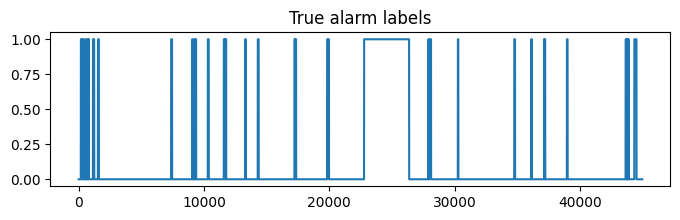

In [112]:
plt.figure(figsize=(8, 2))
plt.plot(test_true_labels)
plt.title('True alarm labels')

# show alarm rates
print('Alarm rate: {:.3f}'.format((test_true_labels == 1).sum() / len(test_true_labels)))

In [113]:
test_batch = next(iter(test_loader)).to(cfg.device)
g = pyg_utils.to_networkx(test_batch[0])

# get initial adjacency matrix
adj_init = nx.adjacency_matrix(g).toarray()
adj_init

array([[0, 1, 1, ..., 1, 1, 1],
       [1, 0, 1, ..., 1, 1, 1],
       [1, 1, 0, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 0, 1, 1],
       [1, 1, 1, ..., 1, 0, 1],
       [1, 1, 1, ..., 1, 1, 0]], shape=(45, 45))

#### Visualize the learned graph

In [114]:
def compute_graph(model: nn.Module, batch):

    batch = batch.to(cfg.device)

    # Do a forward pass in the model
    with torch.no_grad():
        model(batch, None)

    coeff_weights = model.gnn_layers[0].att_weight_1.detach()
    edge_index = model.gnn_layers[0].edge_index_1.detach()
    A = to_dense_adj(edge_index, edge_attr=coeff_weights, batch=batch.batch).squeeze().cpu().numpy()
    return A

In [115]:
adj_test = compute_graph(model, test_batch)
adj_test.shape

(256, 45, 45)

The following code visualizes edges with highest attention score between the provided central node (abnormal node under attack) and the most affected nodes

In [116]:
def plot_central_node(adj, central_node_id, edge_weight_threshold=0.1, topk=None):
    # fix random seed for reproducibility
    np.random.seed(980452)

    anomaly_node_size = 80
    default_node_size = 20

    central_node_color = "yellow"
    anomaly_node_color = "red"
    default_node_color = "black"

    anomaly_edge_color = "red"
    default_edge_color = (0.35686275, 0.20392157, 0.34901961, 0.1)

    feature_num = cfg.dataset.n_nodes

    central_node = int(central_node_id)

    # Find the neighboring nodes and selected the edges with highest value
    scores = np.stack([adj[central_node], adj[:, central_node]], axis=1)
    scores = np.max(scores, axis=1)

    if topk is None:
        # Define red nodes as the nodes with edge weight > edge_weight_threshold
        red_nodes = list(np.where(scores > edge_weight_threshold)[0])
    else:
        red_nodes = list(np.argsort(scores)[::-1][:topk])

    G = nx.from_numpy_array(adj)
    G.remove_edges_from(nx.selfloop_edges(G))

    edges = [set(edge) for edge in G.edges()]
    edge_colors = [default_edge_color for edge in edges]

    node_colors = [default_node_color for i in range(feature_num)]
    node_sizes = [default_node_size for i in range(feature_num)]

    node_colors[central_node] = central_node_color
    node_sizes[central_node] = anomaly_node_size

    for node in red_nodes:
        if node == central_node:
            continue

        node_colors[node] = anomaly_node_color
        node_sizes[node] = anomaly_node_size

        edge_pos = edges.index(set((node, central_node)))
        edge_colors[edge_pos] = anomaly_edge_color

    pos = nx.spring_layout(G)

    x, y = pos[central_node]
    plt.text(x-0.05,y + 0.1,
                s=feature_map[central_node],
                bbox=dict(facecolor=central_node_color, alpha=0.5), horizontalalignment='center')

    print("Central Node:", feature_map[central_node])

    for node in red_nodes:
        x, y = pos[node]
        plt.text(x-0.05,y + 0.1,
                    s=feature_map[node],
                    bbox=dict(facecolor=anomaly_node_color, alpha=0.5), horizontalalignment='center')

        print("Red Node:", feature_map[node])

    nx.draw(G, pos,
            edge_color=edge_colors,
            node_color=node_colors,
            node_size=node_sizes)


Central Node: 41: PIT502
Central Node: PIT502
Red Node: AIT402
Red Node: LIT301


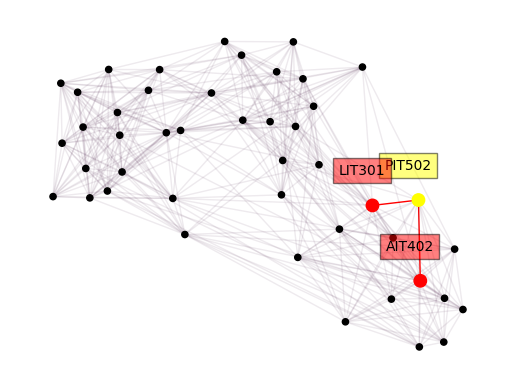

In [117]:
time_index = 200
central_node = test_score[200].argmax()
print(f"Central Node: {central_node}: {feature_map[central_node]}")

plot_central_node(adj_test[time_index], central_node, topk=2)

#### Explain attack scenario

In [118]:
adj_matrices = []
for batch in test_loader:
    batch = batch.to(cfg.device)
    adj = compute_graph(model, batch)
    adj_matrices.append(adj)

adj_matrices = np.concatenate(adj_matrices, axis=0)

#### Inspect the following alarms that you have explored in the file gnn_ex2.1_swat_data_expl.ipynb
- LIT301: 2015-12-29T11:57:25 - 2015-12-29T12:02:00 = 275 seconds
- MV101: 2015-12-29T18:30:00 - 2015-12-29T18:42:00 = 720 seconds

![SWaT Process](img/swat_process.png)

Central Node: PIT502
Red Node: AIT402
Red Node: LIT301


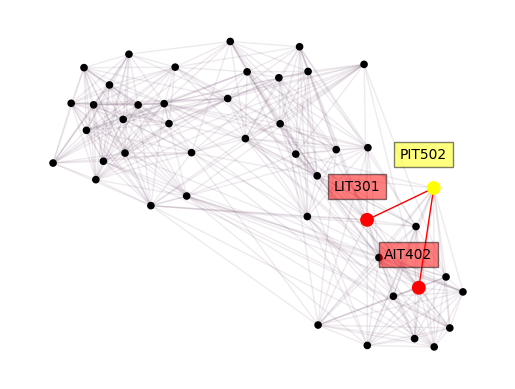

In [119]:
time_index = 9344
plot_central_node(adj_matrices[time_index], central_node_id=central_node, topk=2)

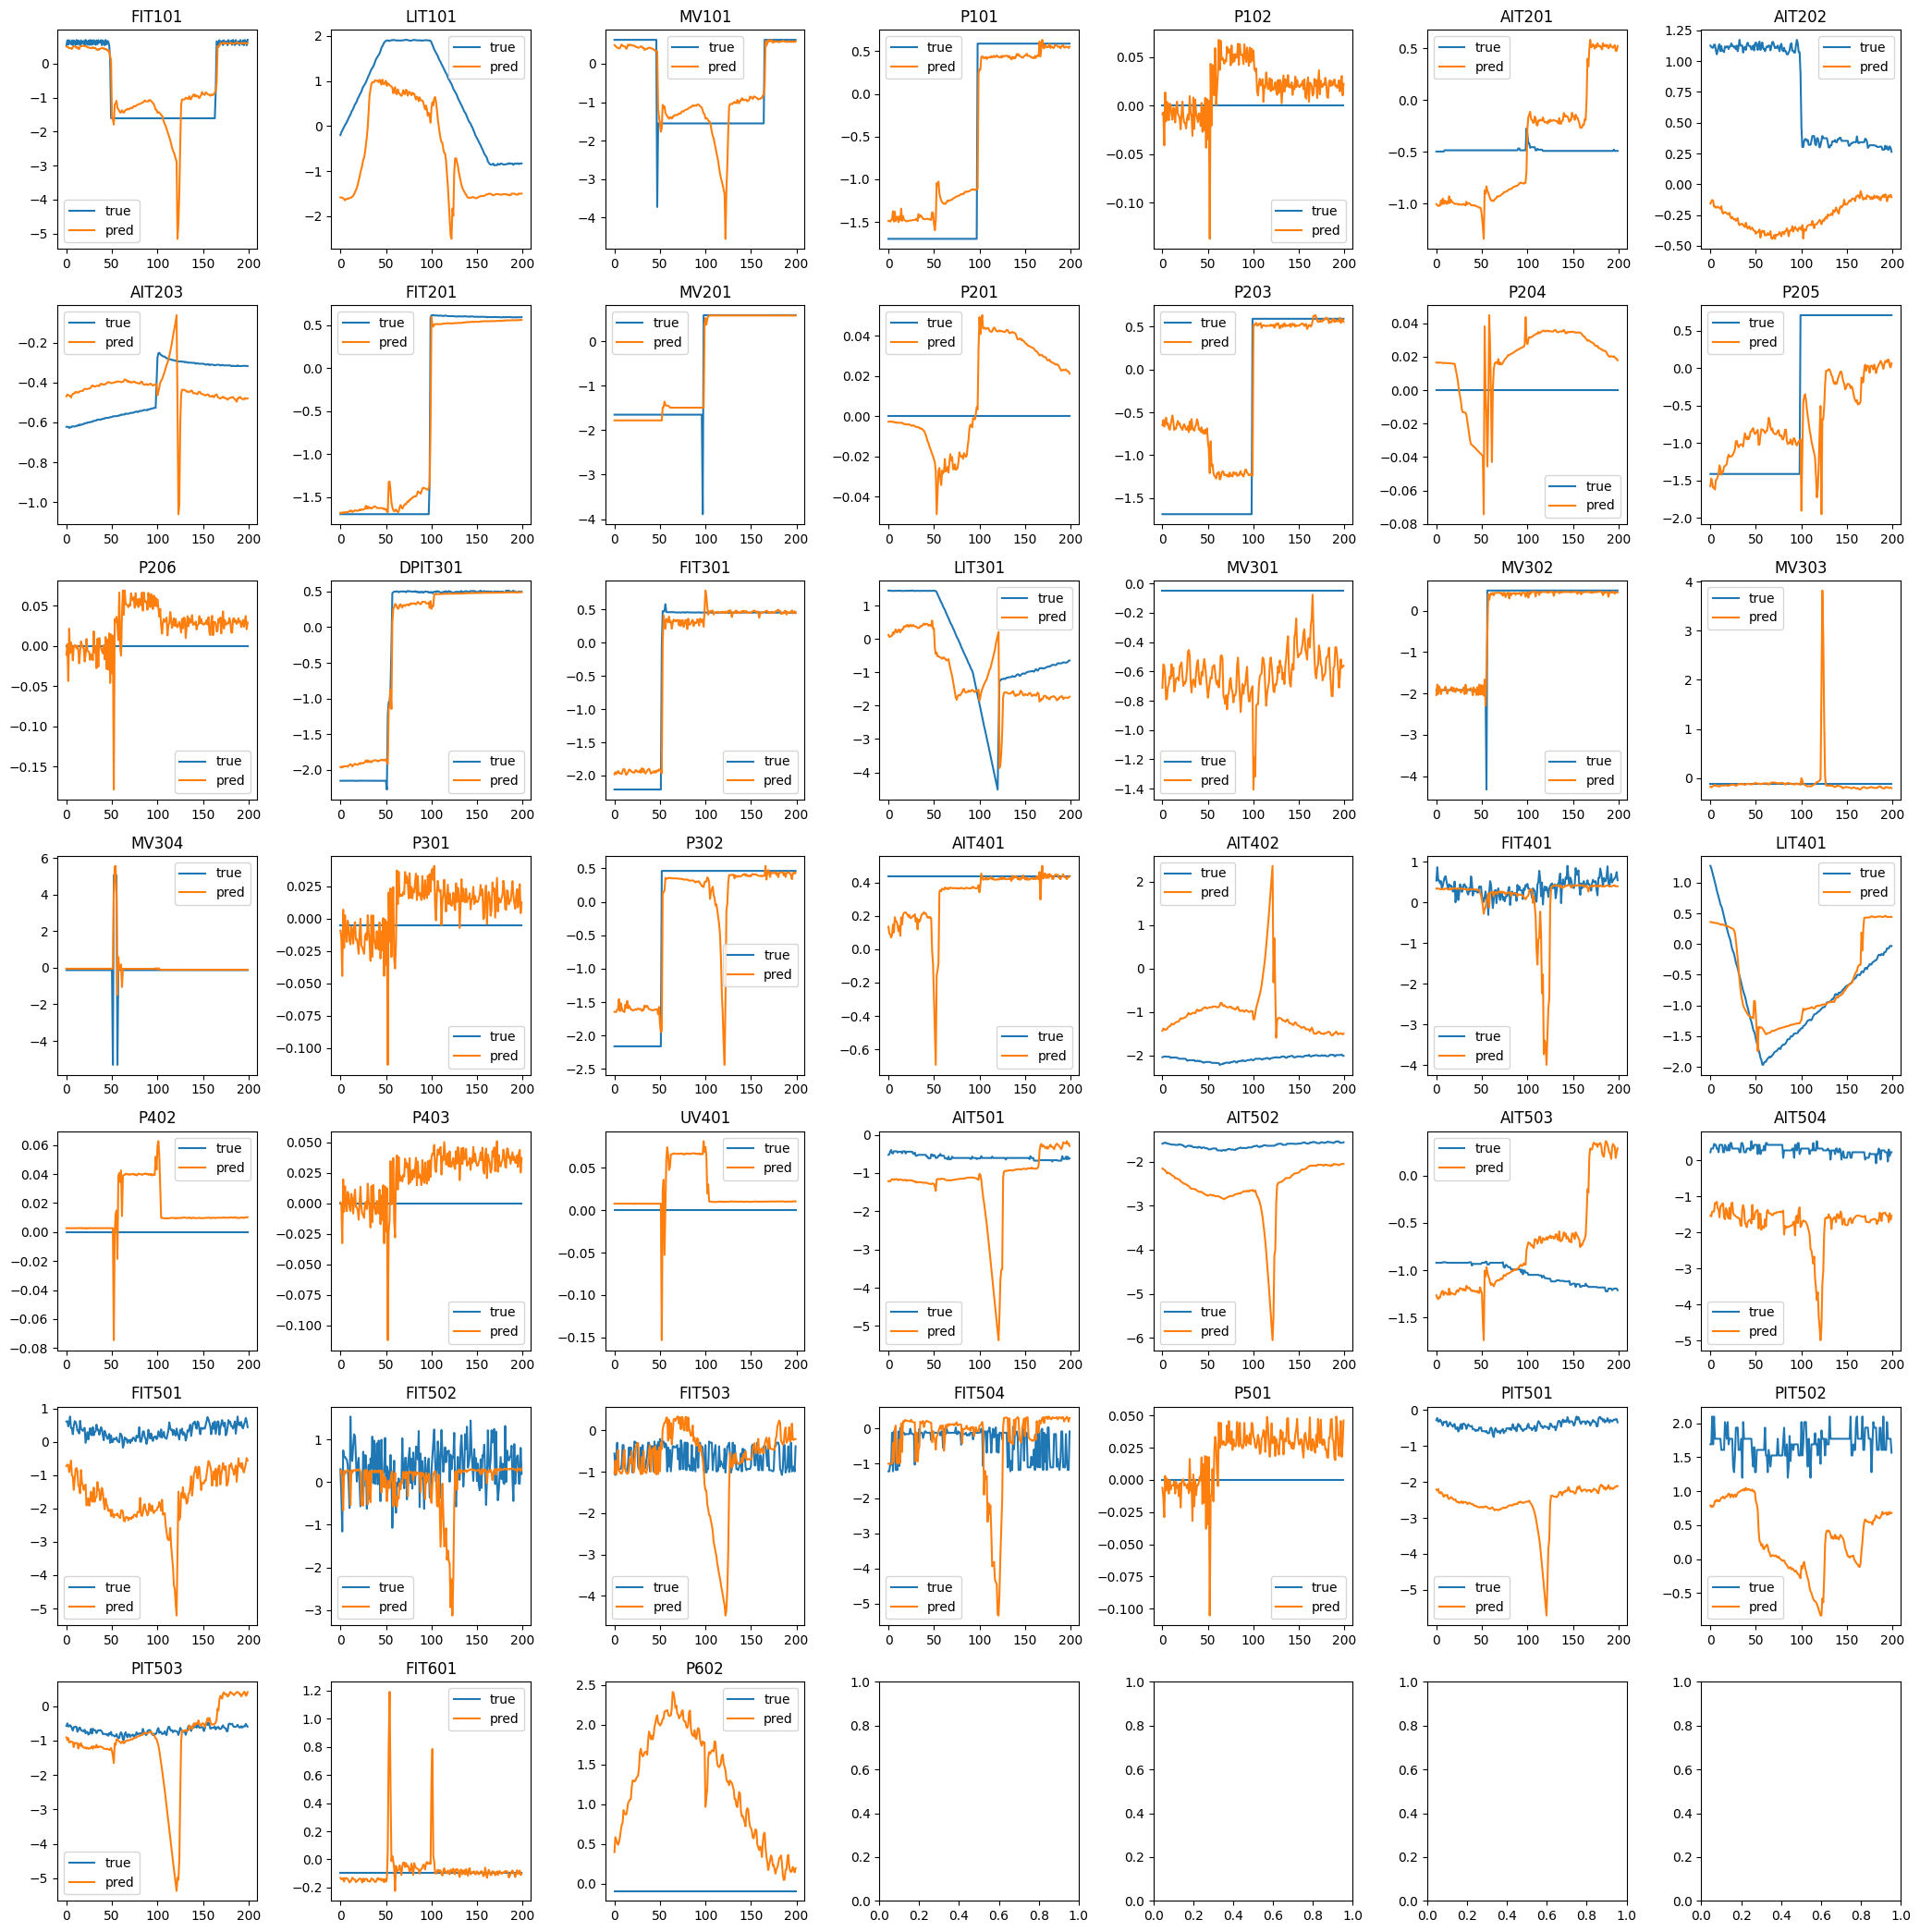

In [120]:
f = plot_node_forecasting(test_preds[:, 0], test_trues[:, 0], idx_range=(time_index-100, time_index+100), labels=list(feature_map.values()))
plt.tight_layout()

Central Node: PIT502
Red Node: AIT402
Red Node: AIT502
Red Node: AIT202
Red Node: AIT203
Red Node: LIT101
Red Node: MV303
Red Node: AIT504
Red Node: P602
Red Node: MV301
Red Node: P205


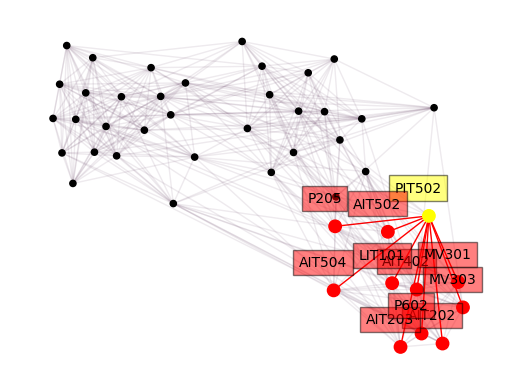

In [34]:
time_index = 11720
plot_central_node(adj_matrices[time_index], central_node_id=central_node, topk=10)